# Install MuJoCo, MJX, and Brax
(Adapted from official MJX tutorial colab)

## Dependecies
Install Mujoco, MJX, and Brax

- Install jax with cuda (usually pip install jax[cuda12]
- Install Mujoco, MJX and Brax (pip install mujoco mujoco_mjx brax)
- Install ffmpeg (sudo apt update && sudo apt install -y ffmpeg)
- Install matplotlib and mediapy (pip install -q mediapy)

In [1]:
# Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

Mon Jul  1 14:18:20 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.52.04              Driver Version: 555.52.04      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080        Off |   00000000:2D:00.0  On |                  N/A |
| 44%   59C    P3             58W /  320W |    1895MiB /  10240MiB |     13%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import packages for plotting and creating graphics
import time
import itertools
import numpy as np
from typing import Callable, NamedTuple, Optional, Union, List

import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [27]:
# Import MuJoCo, MJX, and Brax

from datetime import datetime
import functools
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
import numpy as np
from typing import Any, Dict, Sequence, Tuple, Union

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model

from etils import epath
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx


## Test PSM Push Block Scene

##### Import the scene and create a video to make sure scene is functioning properly

In [5]:
# Make model, data, and renderer
mj_model = mujoco.MjModel.from_xml_path('../descriptions/mujoco_scenes/mjx_pushblock.xml')
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model)

# Place on device (mjx)
mjx_model = mjx.put_model(mj_model)
mjx_data = mjx.put_data(mj_model, mj_data)

# Print qpos from both CPU and GPU model/data
print(mj_data.qpos, type(mj_data.qpos))
print(mjx_data.qpos, type(mjx_data.qpos), mjx_data.qpos.devices())

[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.014 1.
 0.    0.    0.   ] <class 'numpy.ndarray'>
[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.014 1.
 0.    0.    0.   ] <class 'jaxlib.xla_extension.ArrayImpl'> {cuda(id=0)}


/home/mustafa/miniconda3/envs/mujoco/lib/python3.12/site-packages/jax/_src/interpreters/xla.py:155: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


##### Run the simulation and collect a trajectory (CPU Mode)

In [6]:
# enable joint visualization option:
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True

duration = 3  # (seconds)
framerate = 60  # (Hz)

frames = []
mujoco.mj_resetData(mj_model, mj_data)
while mj_data.time < duration:
    mujoco.mj_step(mj_model, mj_data)
    if len(frames) < mj_data.time * framerate:
        renderer.update_scene(mj_data, scene_option=scene_option)
        pixels = renderer.render()
        frames.append(pixels)

# Simulate and display video.
media.show_video(frames, fps=framerate)

##### Run the simulation with MJX and collect a trajectory


In [7]:
jit_step = jax.jit(mjx.step)

frames = []
mujoco.mj_resetData(mj_model, mj_data)
mjx_data = mjx.put_data(mj_model, mj_data)
while mjx_data.time < duration:
  mjx_data = jit_step(mjx_model, mjx_data)
  if len(frames) < mjx_data.time * framerate:
    mj_data = mjx.get_data(mj_model, mjx_data)
    renderer.update_scene(mj_data, scene_option=scene_option)
    pixels = renderer.render()
    frames.append(pixels)

media.show_video(frames, fps=framerate)

##### Test parallelization with 4096 environments

In [8]:
rng = jax.random.PRNGKey(0)
rng = jax.random.split(rng, 4096)
batch = jax.vmap(lambda rng: mjx_data.replace(qpos=jax.random.uniform(rng, (19,))))(rng)

jit_step = jax.jit(jax.vmap(mjx.step, in_axes=(None, 0)))
batch = jit_step(mjx_model, batch)

print(batch.qpos)

[[0.489 0.984 0.317 ... 0.39  0.888 0.232]
 [0.725 0.104 0.208 ... 0.093 0.903 0.331]
 [0.985 0.942 0.955 ... 0.553 0.73  0.388]
 ...
 [0.062 0.874 0.089 ... 0.429 0.531 0.631]
 [0.226 0.958 0.121 ... 0.535 0.328 0.664]
 [0.741 0.628 0.683 ... 0.151 0.76  0.342]]


# Environment Setup
##### Test kinematics

In [22]:
# PSM Kinematics

PI = np.pi
PI_2 = np.pi/2

def mat_from_dh_revolute(alpha, a, theta, d, offset):
    ca = jp.cos(alpha)
    sa = jp.sin(alpha)
    th = 0.0
    th = theta + offset
    ct = jp.cos(th)
    st = jp.sin(th)
    mat = jp.asarray([
            [ct, -st, 0, a],
            [st * ca, ct * ca, -sa, -d * sa],
            [st * sa, ct * sa, ca, d * ca],
            [0, 0, 0, 1]])
    return mat

def mat_from_dh_prismatic(alpha, a, theta, d, offset):
    ca = jp.cos(alpha)
    sa = jp.sin(alpha)
    th = 0.0
    d = d + offset + theta
    ct = jp.cos(th)
    st = jp.sin(th)
    mat = jp.asarray([
        [ct, -st, 0, a],
        [st * ca, ct * ca, -sa, -d * sa],
        [st * sa, ct * sa, ca, d * ca],
        [0, 0, 0, 1]])
    return mat

def compute_psm_fk_up_to_3(joint_pos, l_rcc=0.4318):
    T_3_0 = jp.identity(4)
    T_1_0 = mat_from_dh_revolute(PI_2, 0, joint_pos[0], 0, PI_2)
    T_2_1 = mat_from_dh_revolute(-PI_2, 0, joint_pos[1], 0, -PI_2)
    T_3_2 = mat_from_dh_prismatic(PI_2, 0, joint_pos[2], 0, -l_rcc)

    T_3_0 = jp.matmul(T_3_0, T_1_0)
    T_3_0 = jp.matmul(T_3_0, T_2_1)
    T_3_0 = jp.matmul(T_3_0, T_3_2)

    return T_3_0

def compute_psm_fk(joint_pos, l_rcc=0.4318, l_tool=0.4162, l_yaw2ctrlpnt=0.0102, l_pitch2yaw=0.0091):
    T_7_0 = compute_psm_fk_up_to_3(joint_pos[:3])
    T_4_3 = mat_from_dh_revolute(0, 0, joint_pos[3], l_tool, 0)
    T_5_4 = mat_from_dh_revolute(-PI_2, 0, joint_pos[4], 0, -PI_2)
    T_6_5 = mat_from_dh_revolute(-PI_2, l_pitch2yaw, joint_pos[5], 0, -PI_2)
    T_7_6 = mat_from_dh_revolute(-PI_2, 0, 0, l_yaw2ctrlpnt, PI_2)

    T_7_0 = jp.matmul(T_7_0, T_4_3)
    T_7_0 = jp.matmul(T_7_0, T_5_4)
    T_7_0 = jp.matmul(T_7_0, T_6_5)
    T_7_0 = jp.matmul(T_7_0, T_7_6)

    return T_7_0

def compute_psm_ik(T_7_0, l_rcc=0.4318, l_tool=0.4162, l_yaw2ctrlpnt=0.0102, l_pitch2yaw=0.0091) -> jax.Array:
    l_tool2rcm_offset = l_rcc - l_tool
    T_Pinch_7 = jp.identity(4)
    T_Pinch_7 = T_Pinch_7.at[2, 3].set(-l_yaw2ctrlpnt)
    #T_Pinch_7[0:3, 3] = [0.0, 0.0, -l_yaw2ctrlpnt]

    T_Pinch_0 = jp.matmul(T_7_0, T_Pinch_7)

    R_0_Pinch = jp.linalg.inv(T_Pinch_0[0:3, 0:3])
    P_Pinch_local = jp.dot(R_0_Pinch, T_Pinch_0[0:3, 3])
    N_Palm_Pinch = -P_Pinch_local
    N_Palm_Pinch = N_Palm_Pinch.at[0].set(0)
    #N_Palm_Pinch[0] = 0
    N_Palm_Pinch = N_Palm_Pinch / jp.linalg.norm(N_Palm_Pinch)

    T_Palm_Pinch = jp.identity(4)
    T_Palm_Pinch = T_Palm_Pinch.at[0:3, 3].set(N_Palm_Pinch * l_pitch2yaw)
    #T_Palm_Pinch[0:3, 3] = N_Palm_Pinch * l_pitch2yaw

    T_Palm_0 = jp.matmul(jp.matmul(T_7_0, T_Pinch_7), T_Palm_Pinch)
    insertion_depth = jp.linalg.norm(T_Palm_0[0:3, 3])

    xz_diagonal = jp.sqrt(T_Palm_0[0, 3] ** 2 + T_Palm_0[2, 3] ** 2)

    j1 = jp.arctan2(T_Palm_0[0, 3], -T_Palm_0[2, 3])
    j2 = -jp.arctan2(T_Palm_0[1, 3], xz_diagonal)
    j3 = insertion_depth + l_tool2rcm_offset

    # Calculate j4
    cross_palmlink_x7_0 = jp.cross(T_7_0[0:3, 0], (T_Pinch_0[0:3, 3] - T_Palm_0[0:3, 3]))
    T_3_0 = compute_psm_fk_up_to_3([j1, j2, j3])
    T_3_0_RY = jp.squeeze(jp.asarray(T_3_0.T[1, :3]))
    T_3_0_RZ = jp.squeeze(jp.asarray(T_3_0.T[2, :3]))
    j4 = math.signed_angle(-T_3_0_RZ, cross_palmlink_x7_0, T_3_0_RY)

    # Calculate j5
    T_4_3 = mat_from_dh_revolute(0, 0, j4, l_tool, 0)
    T_4_0 = jp.matmul(T_3_0, T_4_3)
    T_4_0_RY = jp.squeeze(jp.asarray(T_4_0.T[1, :3]))
    T_4_0_RZ = jp.squeeze(jp.asarray(T_4_0.T[2, :3]))
    j5 = math.signed_angle(-T_4_0_RY, T_Pinch_0.T[3, :3] - T_Palm_0.T[3, :3], T_4_0_RZ)

    # Calculate j6
    T_5_4 = mat_from_dh_revolute(-PI_2, 0, j5, 0, -PI_2)
    T_5_0 = jp.matmul(T_4_0, T_5_4)
    T_7_0_RZ = jp.squeeze(jp.asarray(T_7_0.T[2, :3]))
    T_5_0_RX = jp.squeeze(jp.asarray(T_5_0.T[0, :3]))
    T_5_0_RY = jp.squeeze(jp.asarray(T_5_0.T[1, :3]))
    j6 = math.signed_angle(-T_5_0_RY, T_7_0_RZ, T_5_0_RX)

    return jp.asarray([j1, j2, j3, j4, j5, j6])

# Test FK-IK
i = jp.asarray([-1.1, 0.2, 0.1, 0, 0.4, 0])
jointpos = compute_psm_fk(i)
cp = compute_psm_ik(jointpos)
print("Input " + str(i))
print("Output " + str(cp))

Input [-1.1  0.2  0.1  0.   0.4  0. ]
Output [-1.1  0.2  0.1 -0.   0.4  0. ]


##### Setup Environment

In [24]:
# Push Block Env

from brax.base import Transform

class PushBlock(PipelineEnv):

  def __init__(
      self,
      x_spawn_range=(-0.08, 0.08),
      y_spawn_range=(-0.07, 0.06),
      distance_reward_weight=1.25,
      goal_reward=5.0,
      **kwargs,
  ):
    mj_model = mujoco.MjModel.from_xml_path('../descriptions/mujoco_scenes/mjx_pushblock.xml')
    mj_model.opt.solver = mujoco.mjtSolver.mjSOL_CG
    mj_model.opt.iterations = 6
    mj_model.opt.ls_iterations = 6

    sys = mjcf.load_model(mj_model)

    physics_steps_per_control_step = 5
    kwargs['n_frames'] = kwargs.get(
        'n_frames', physics_steps_per_control_step)
    kwargs['backend'] = 'mjx'

    super().__init__(sys, **kwargs)
      
    self._distance_reward_weight = distance_reward_weight
    self._goal_reward = goal_reward
    self._x_spawn_range = x_spawn_range
    self._y_spawn_range = y_spawn_range
      
    self._start_q = [0, 0, 0.115, 0, 0, 0]
    self._start_tiptransform = compute_psm_fk(self._start_q)
    self._speed_multiplier = 0.005


    self._goal_pos = mj_model.geom_pos[mj_model.geom('goal').id]
    self._tooltip_id = mj_model.site('tool_tip').id
    self._block_id = mj_model.body('block').id
    self._base_id = mj_model.body('base_link').id

  @property
  def action_size(self) -> int:
    return 2

  def reset(self, rng: jp.ndarray) -> State:
    """Resets the environment to an initial state."""
    rng, rng1, rng2 = jax.random.split(rng, 3)

    x = jax.random.uniform(rng1, (1,), minval=self._x_spawn_range[0], maxval=self._x_spawn_range[1])      
    y = jax.random.uniform(rng1, (1,), minval=self._y_spawn_range[0], maxval=self._y_spawn_range[1])

    qpos = self.sys.qpos0
    qpos = qpos.at[4].set(0.115)
    qpos = qpos.at[12].set(x[0])
    qpos = qpos.at[13].set(y[0])
    qvel = jp.zeros(self.sys.nv)
    data = self.pipeline_init(qpos, qvel)

    current_transform = compute_psm_fk(self._start_q)

    obs = self._get_obs(data, jp.zeros(self.sys.nu))
    reward, done, zero = jp.zeros(3)
    metrics = {
        'distance_reward': zero,
        'goal_reward': zero,
        'x_position': zero,
        'y_position': zero,
    }
    info = {
        'current_pos' : current_transform[:3, 3]
    }
    return State(data, obs, reward, done, metrics, info)

  def step(self, state: State, action: jp.ndarray) -> State:
    """Runs one timestep of the environment's dynamics."""
    data0 = state.pipeline_state
    info = state.info

    new_tipposition = info['current_pos']
    scaled_action = action * self._speed_multiplier
    new_tipposition = new_tipposition.at[:2].add(action)
    new_tipposition = jp.clip(new_tipposition, -0.17, 0.17)

    current_tippose = self._start_tiptransform
    current_tippose = current_tippose.at[:3, 3].set(new_tipposition)
    jointpos = compute_psm_ik(current_tippose)
    jointpos_withjaw = jp.append(jointpos, 0)
    data = self.pipeline_step(data0, jointpos_withjaw)

    info['current_pos'] = new_tipposition

    distance_reward = 1 - (6 * jp.abs(data.q[13] - 0.08))
    goal_reached = jp.where(data.q[13] > 0.08, 1.0, 0.0)
    goal_reward = goal_reached * self._goal_reward

    obs = self._get_obs(data, action)
    reward = goal_reward
    done = goal_reached

    state.metrics.update(
        distance_reward=distance_reward,
        goal_reward=goal_reward,
        x_position=data.q[12],
        y_position=data.q[13]
    )

    return state.replace(
        pipeline_state=data, obs=obs, reward=reward, done=done, info=info
    )

  def _get_obs(
      self, data: mjx.Data, action: jp.ndarray
  ) -> jp.ndarray:
    """Observes humanoid body position, velocities, and angles."""

    tooltip_to_goal = self._goal_pos - data.site_xpos[self._tooltip_id]
    tooltip_to_block = data.xpos[self._block_id] - data.site_xpos[self._tooltip_id]
    goal_to_block = data.xpos[self._block_id] - self._goal_pos

    # external_contact_forces are excluded
    return jp.concatenate([
        tooltip_to_goal,
        tooltip_to_block,
        goal_to_block
    ])

envs.register_environment('pushblock', PushBlock)

##### Visualize a Rollout

In [25]:
# instantiate the environment
env_name = 'pushblock'
env = envs.get_environment(env_name)

# define the jit reset/step functions
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

# initialize the state
state = jit_reset(jax.random.PRNGKey(2))
rollout = [state.pipeline_state]

# grab a trajectory
for i in range(70):
    #ctrl = jp.zeros(env.sys.nu)
    ctrl = jp.array([0, 1])
    state = jit_step(state, ctrl)
    rollout.append(state.pipeline_state)

media.show_video(env.render(rollout), fps=1.0 / env.dt)

## Train PushBlock Policy

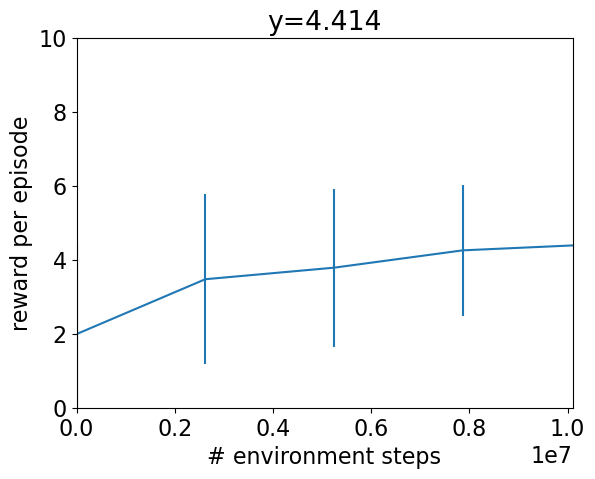

time to jit: 0:00:38.155281
time to train: 0:02:30.368378


In [29]:
train_fn = functools.partial(
    ppo.train, num_timesteps=10_000_000, num_evals=5, reward_scaling=0.1,
    episode_length=1000, normalize_observations=True, action_repeat=1,
    unroll_length=10, num_minibatches=32, num_updates_per_batch=8,
    discounting=0.97, learning_rate=3e-4, entropy_cost=1e-3, num_envs=2048,
    batch_size=1024, seed=0)

xdata, ydata, ydataerr = [], [], []
times = [datetime.now()]

max_y, min_y = 10, 0
def progress(num_steps, metrics):
  times.append(datetime.now())
  xdata.append(num_steps)
  ydata.append(metrics['eval/episode_reward'])
  ydataerr.append(metrics['eval/episode_reward_std'])

  clear_output(wait=True)
  plt.rcParams.update({'font.size': 16})
  plt.xlim([0, train_fn.keywords['num_timesteps'] * 1.01])
  plt.ylim([min_y, max_y])
  plt.xlabel('# environment steps')
  plt.ylabel('reward per episode')
  plt.title(f'y={ydata[-1]:.3f}')
  plt.errorbar(xdata, ydata, yerr=ydataerr)
  plt.show()

make_inference_fn, params, _= train_fn(environment=env, progress_fn=progress)
jit_inference_fn = jax.jit(make_inference_fn(params))

print(f'time to jit: {times[1] - times[0]}')
print(f'time to train: {times[-1] - times[1]}')

## Save and Visualize Policy

In [30]:
# Save Model
model_path = '/tmp/mjx_brax_policy'
model.save_params(model_path, params)

# Load Model and Visualize
params = model.load_params(model_path)

eval_env = envs.get_environment(env_name)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)

# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
rollout = [state.pipeline_state]

# grab a trajectory
n_steps = 500
render_every = 1

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

  if state.done:
    break

media.show_video(env.render(rollout[::render_every]), fps=0.1 / env.dt)

This browser does not support the video tag.


## Transfer Policy to Mujoco

In [ ]:
mj_model = eval_env.sys.mj_model
mj_data = mujoco.MjData(mj_model)

renderer = mujoco.Renderer(mj_model)
ctrl = jp.zeros(mj_model.nu)

images = []
for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)

  obs = eval_env._get_obs(mjx.put_data(mj_model, mj_data), ctrl)
  ctrl, _ = jit_inference_fn(obs, act_rng)

  mj_data.ctrl = ctrl
  for _ in range(eval_env._n_frames):
    mujoco.mj_step(mj_model, mj_data)  # Physics step using MuJoCo mj_step.

  if i % render_every == 0:
    renderer.update_scene(mj_data)
    images.append(renderer.render())

media.show_video(images, fps=1.0 / eval_env.dt / render_every)